# Assignment 2: Training and Visualizing a CNN on CIFAR-10
---
This notebook covers **Task 1** (CNN design, training, evaluation) and **Task 2** (feature map visualization and maximally activating images).

The images in CIFAR-10 are small 32x32 color images that fall into one of ten classes.

<img src='cifar_data.png' width=50% height=50% />

## 0. Imports and GPU Check
Make sure your Colab runtime is set to GPU: **Runtime -> Change runtime type -> T4 GPU** (or better).

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
%matplotlib inline

# ── All output files go here — explicit absolute path, always findable ─────────
SAVE_DIR = '/content/'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ─────────────────────────────────────────────────────────────────────
train_on_gpu = torch.cuda.is_available()
device = torch.device('cuda' if train_on_gpu else 'cpu')

if not train_on_gpu:
    print('CUDA is not available. Training on CPU (will be slow)...')
else:
    print(f'CUDA is available! Training on GPU: {torch.cuda.get_device_name(0)}')

print(f'PyTorch version : {torch.__version__}')
print(f'Output directory: {SAVE_DIR}')

CUDA is available! Training on GPU: NVIDIA A100-SXM4-40GB
PyTorch version : 2.10.0+cu128
Output directory: /content/


## 1. Load the Data (CIFAR-10)
---
### Training Setup Summary
| Hyperparameter | Value |
|---|---|
| Dataset | CIFAR-10 |
| Batch size | 128 |
| Validation split | 20% of training set |
| Loss function | CrossEntropyLoss |
| Optimizer | Adam (lr=0.001, weight_decay=1e-4) |
| Learning rate | 0.001 |
| LR scheduler | CosineAnnealingLR (T_max=30) |
| Epochs | 30 |
| Regularization | Dropout (p=0.5), Weight decay (1e-4) |
| Data augmentation | RandomHorizontalFlip, RandomCrop(32, padding=4), ColorJitter |

In [2]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
batch_size    = 128
valid_size    = 0.2
n_epochs      = 30
learning_rate = 0.001

# num_workers=2 is fine on Colab GPU; fall back to 0 on CPU to avoid deadlocks
num_workers = 2 if train_on_gpu else 0
pin_memory  = train_on_gpu

# ── CIFAR-10 channel-wise mean and std (pre-computed from the training set) ────
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

# Training transform — includes data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Eval transform — no augmentation, only normalize (used for validation AND test)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Download datasets
# train_data uses augmentation; valid_data uses eval_transform on the same images
# so validation loss is not inflated by random augmentation
train_data = datasets.CIFAR10('/content/data', train=True,  download=True, transform=train_transform)
valid_data = datasets.CIFAR10('/content/data', train=True,  download=True, transform=eval_transform)
test_data  = datasets.CIFAR10('/content/data', train=False, download=True, transform=eval_transform)

# Train / validation index split
num_train = len(train_data)
indices   = list(range(num_train))
np.random.shuffle(indices)
split      = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=batch_size, sampler=train_sampler,
    num_workers=num_workers, pin_memory=pin_memory)

valid_loader = torch.utils.data.DataLoader(
    valid_data, batch_size=batch_size, sampler=valid_sampler,
    num_workers=num_workers, pin_memory=pin_memory)

test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=pin_memory)

# Class labels — CIFAR-10 official order (index 0–9)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Training samples   : {len(train_idx):,}')
print(f'Validation samples : {len(valid_idx):,}')
print(f'Test samples       : {len(test_data):,}')
print(f'Batches per epoch  : {len(train_loader)}')

100%|██████████| 170M/170M [00:02<00:00, 61.2MB/s]


Training samples   : 40,000
Validation samples : 10,000
Test samples       : 10,000
Batches per epoch  : 313


### Visualize a Batch of Training Data

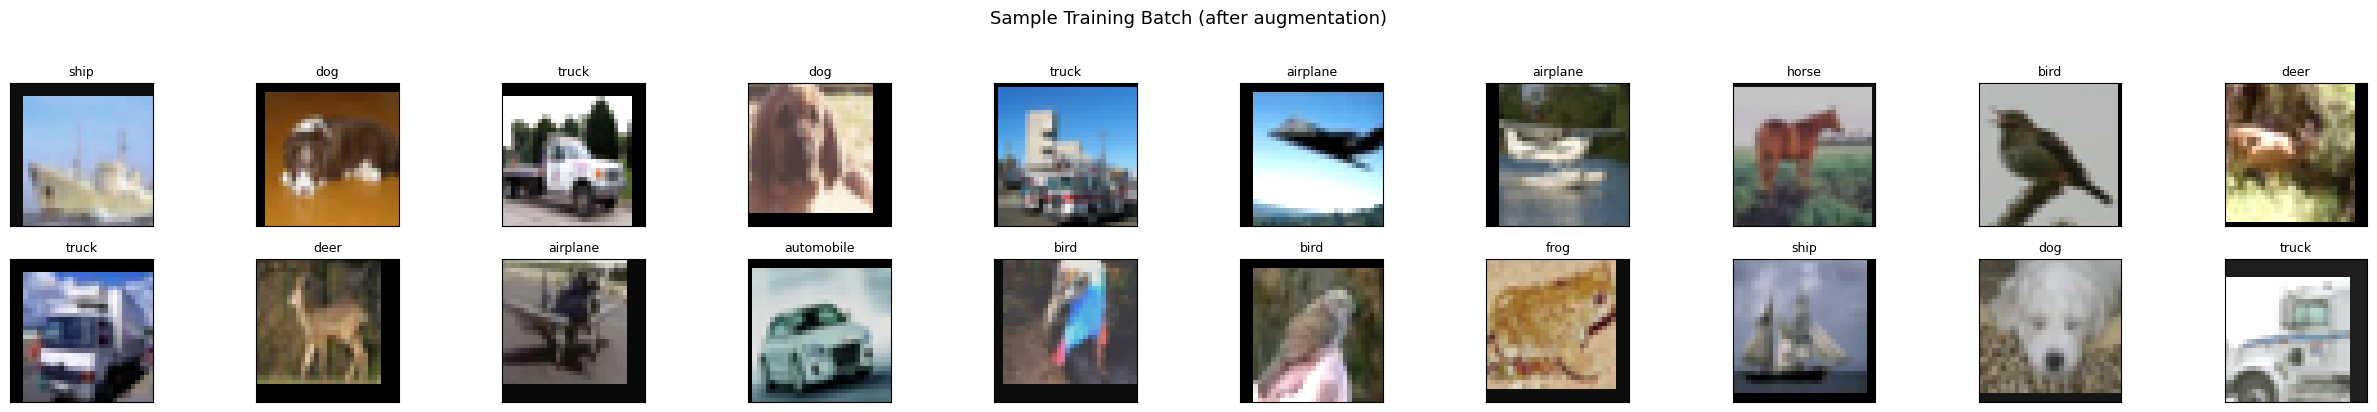

In [3]:
def imshow(img_tensor):
    """Un-normalize a CHW tensor and display it. Works for CPU and GPU tensors."""
    img = img_tensor.cpu().clone().numpy()   # .cpu() ensures this works on GPU tensors too
    for c in range(3):
        img[c] = img[c] * CIFAR_STD[c] + CIFAR_MEAN[c]
    img = np.clip(img, 0, 1)
    plt.imshow(np.transpose(img, (1, 2, 0)))

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(25, 4))
for idx in range(20):
    ax = fig.add_subplot(2, 10, idx + 1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]], fontsize=9)
plt.suptitle('Sample Training Batch (after augmentation)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. Define the CNN Architecture
---
### Architecture Overview

| Layer | Type | Output Shape | Details |
|---|---|---|---|
| Input | — | 3x32x32 | CIFAR-10 RGB image |
| Conv Block 1 | Conv2d + BN + ReLU + MaxPool | 32x16x16 | 32 filters, 3x3, pad=1 |
| Conv Block 2 | Conv2d + BN + ReLU + MaxPool | 64x8x8 | 64 filters, 3x3, pad=1 |
| Conv Block 3 | Conv2d + BN + ReLU + MaxPool | 128x4x4 | 128 filters, 3x3, pad=1 |
| Flatten | — | 2048 | 128 x 4 x 4 |
| FC1 | Linear + ReLU + Dropout(0.5) | 512 | |
| FC2 (output) | Linear | 10 | Raw logits |

In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # Conv Block 1: 3x32x32 -> 32x16x16
        self.conv1 = nn.Conv2d(3,   32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # Conv Block 2: 32x16x16 -> 64x8x8
        self.conv2 = nn.Conv2d(32,  64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Conv Block 3: 64x8x8 -> 128x4x4
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # Shared 2x2 max-pooling (halves spatial dims each use)
        self.pool = nn.MaxPool2d(2, 2)

        # After 3 pooling ops: 128 channels x 4 x 4 = 2048
        self.fc1     = nn.Linear(128 * 4 * 4, 512)
        self.fc2     = nn.Linear(512, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 32x16x16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 64x8x8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 128x4x4
        x = x.view(x.size(0), -1)                       # flatten -> 2048
        x = self.dropout(F.relu(self.fc1(x)))            # 512
        x = self.fc2(x)                                  # 10 logits
        return x

model = Net().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total trainable parameters: 1,147,914


## 3. Loss Function, Optimizer, and LR Scheduler

In [5]:
# Cross-Entropy is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam with L2 weight decay as additional regularization
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# Cosine annealing smoothly reduces LR to near 0 over all epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

print('Loss      : CrossEntropyLoss')
print(f'Optimizer : Adam  (lr={learning_rate}, weight_decay=1e-4)')
print(f'Scheduler : CosineAnnealingLR (T_max={n_epochs})')
print(f'Epochs    : {n_epochs}')
print(f'Batch     : {batch_size}')

Loss      : CrossEntropyLoss
Optimizer : Adam  (lr=0.001, weight_decay=1e-4)
Scheduler : CosineAnnealingLR (T_max=30)
Epochs    : 30
Batch     : 128


## 4. Train the Network

In [ ]:
train_losses   = []
valid_losses   = []
valid_loss_min = np.inf

# Explicit absolute path — always saves to /content/ regardless of CWD
MODEL_PATH = os.path.join(SAVE_DIR, 'model_trained.pt')

for epoch in range(1, n_epochs + 1):

    # ── Training phase ─────────────────────────────────────────────────────────
    model.train()
    running_train = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
        running_train += loss.item() * data.size(0)

    # ── Validation phase ───────────────────────────────────────────────────────
    model.eval()
    running_valid = 0.0
    with torch.no_grad():
        for data, target in valid_loader:
            data, target = data.to(device), target.to(device)
            loss = criterion(model(data), target)
            running_valid += loss.item() * data.size(0)

    epoch_train = running_train / len(train_idx)
    epoch_valid = running_valid / len(valid_idx)
    train_losses.append(epoch_train)
    valid_losses.append(epoch_valid)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    print(f'Epoch {epoch:2d}/{n_epochs} | '
          f'Train Loss: {epoch_train:.4f} | '
          f'Val Loss: {epoch_valid:.4f} | '
          f'LR: {current_lr:.6f}')

    if epoch_valid <= valid_loss_min:
        print(f'  -> Val loss improved ({valid_loss_min:.4f} -> {epoch_valid:.4f}). Saving...')
        torch.save(model.state_dict(), MODEL_PATH)
        valid_loss_min = epoch_valid

print(f'\nTraining complete. Best model saved to: {MODEL_PATH}')

Epoch  1/30 | Train Loss: 1.6526 | Val Loss: 1.4372 | LR: 0.000997
  -> Val loss improved (inf -> 1.4372). Saving...
Epoch  2/30 | Train Loss: 1.3075 | Val Loss: 1.0550 | LR: 0.000989
  -> Val loss improved (1.4372 -> 1.0550). Saving...


### Training and Validation Loss Curves

In [ ]:
LOSS_CURVE_PATH = os.path.join(SAVE_DIR, 'loss_curves.png')

fig, ax = plt.subplots(figsize=(9, 5))
ep = range(1, n_epochs + 1)
ax.plot(ep, train_losses, 'b-o', markersize=4, label='Training Loss')
ax.plot(ep, valid_losses, 'r-o', markersize=4, label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training and Validation Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(LOSS_CURVE_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOSS_CURVE_PATH}')

## 5. Test the Trained Network
We reload the best checkpoint (lowest validation loss) before evaluating on the held-out test set.

In [ ]:
# weights_only=True silences the PyTorch 2.x deprecation warning
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

test_loss     = 0.0
class_correct = [0.0] * 10
class_total   = [0.0] * 10

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += criterion(output, target).item() * data.size(0)

        _, pred = torch.max(output, 1)
        correct = pred.eq(target.view_as(pred)).cpu().numpy()

        # Use len(target) not batch_size — handles the final partial batch correctly
        for i in range(len(target)):
            label = target[i].item()
            class_correct[label] += correct[i].item()
            class_total[label]   += 1

test_loss /= len(test_loader.dataset)
print(f'Test Loss: {test_loss:.6f}\n')

for i in range(10):
    if class_total[i] > 0:
        acc = 100 * class_correct[i] / class_total[i]
        print(f'  {classes[i]:>12s}: {acc:5.1f}%  ({int(class_correct[i])}/{int(class_total[i])})')

overall = 100 * sum(class_correct) / sum(class_total)
print(f'\nOverall Test Accuracy: {overall:.1f}%  ({int(sum(class_correct))}/{int(sum(class_total))})')

### Visualize Sample Test Predictions

In [ ]:
dataiter = iter(test_loader)
images, labels = next(dataiter)   # images remain on CPU

model.eval()
with torch.no_grad():
    output = model(images.to(device))   # only the model input goes to GPU
_, preds_tensor = torch.max(output, 1)
preds = preds_tensor.cpu().numpy()

fig = plt.figure(figsize=(25, 4))
for idx in range(20):
    ax = fig.add_subplot(2, 10, idx + 1, xticks=[], yticks=[])
    imshow(images[idx])   # images[idx] is CPU; imshow calls .cpu() internally anyway
    color = 'green' if preds[idx] == labels[idx].item() else 'red'
    ax.set_title(f'{classes[preds[idx]]}\n({classes[labels[idx]]})',
                 color=color, fontsize=8)
plt.suptitle('Predicted (True) — green=correct, red=wrong', fontsize=12)
plt.tight_layout()
plt.show()

---
## Task 2 — Shared Hook Utilities
These are defined **before** both Task 2A and 2B so neither cell can crash with a NameError
if run out of order.

In [ ]:
# Shared dict that forward hooks write into
activation_store = {}

def get_activation(name):
    """Returns a forward hook that stores the layer output in activation_store."""
    def hook(module, input, output):
        activation_store[name] = output.detach().cpu()
    return hook

print('Hook utilities ready.')

---
## Task 2A — Feature Map Visualization (First Convolutional Layer)
---
We select **3 test images from 3 different classes**, pass each through the trained CNN, and extract
feature maps from **Conv Layer 1** (`conv1`). We visualize **16 feature maps** per image (>=8 required).

**What we capture:** Raw output of `conv1` *before* BatchNorm and ReLU via a forward hook.
The RdBu colormap shows positive (blue) and negative (red) filter responses clearly.

In [ ]:
# Pick one test image each from: airplane (0), cat (3), ship (8)
TARGET_CLASSES = [0, 3, 8]
selected_images = {}   # class_idx -> CPU tensor C x H x W

for images_batch, labels_batch in test_loader:
    for img, lbl in zip(images_batch, labels_batch):
        lbl_int = lbl.item()
        if lbl_int in TARGET_CLASSES and lbl_int not in selected_images:
            selected_images[lbl_int] = img   # store on CPU
        if len(selected_images) == len(TARGET_CLASSES):
            break
    if len(selected_images) == len(TARGET_CLASSES):
        break

for cls_idx in TARGET_CLASSES:
    print(f'  Class {cls_idx}: {classes[cls_idx]} — shape {selected_images[cls_idx].shape}')

In [ ]:
N_MAPS = 16   # visualize 16 channels (requirement: >= 8)

hook_handle_2a = model.conv1.register_forward_hook(get_activation('conv1'))
model.eval()

for cls_idx in TARGET_CLASSES:
    img_tensor = selected_images[cls_idx]        # C x H x W, CPU
    inp = img_tensor.unsqueeze(0).to(device)      # 1 x C x H x W, GPU

    with torch.no_grad():
        _ = model(inp)   # forward pass triggers the hook

    # activation_store['conv1'] shape: 1 x 32 x 32 x 32 (batch x channels x h x w)
    fmaps = activation_store['conv1'][0]          # 32 x 32 x 32, all on CPU

    # Layout: 2 rows x 9 cols = 18 axes  (1 original + 16 maps + 1 spare hidden)
    fig, axes = plt.subplots(2, 9, figsize=(18, 4.5))
    axes = axes.flatten()

    # Slot 0: original input image
    orig = img_tensor.cpu().clone().numpy()
    for c in range(3):
        orig[c] = orig[c] * CIFAR_STD[c] + CIFAR_MEAN[c]
    orig = np.clip(orig, 0, 1)
    axes[0].imshow(np.transpose(orig, (1, 2, 0)))
    axes[0].set_title('Original\nInput', fontsize=8, fontweight='bold')
    axes[0].axis('off')

    # Slots 1-16: feature maps for channels 0 to N_MAPS-1
    for i in range(N_MAPS):
        axes[i + 1].imshow(fmaps[i].numpy(), cmap='RdBu_r', interpolation='nearest')
        axes[i + 1].set_title(f'Ch {i}', fontsize=7)
        axes[i + 1].axis('off')

    # Hide any unused axes
    for j in range(N_MAPS + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(
        f'Conv Layer 1 Feature Maps ({N_MAPS} channels shown) | Class: {classes[cls_idx].upper()}',
        fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, f'feature_maps_conv1_{classes[cls_idx]}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

hook_handle_2a.remove()
print('Done — hook removed.')

---
## Task 2B — Maximally Activating Images for Selected Filters
---
**Layer:** `conv1` (first convolutional layer — early layer)  
**Filters selected:** 0, 5, 10  
**Activation metric:** Mean value of ReLU(feature map)  
Each filter produces a 2D spatial activation map per image. We apply ReLU (so values are >= 0),
then take the spatial mean as a single scalar representing that filter's overall response strength.
We find the **top 5** test images with the highest scalar activation for each filter.

In [ ]:
SELECTED_FILTERS = [0, 5, 10]
TOP_K = 5

all_activations = []   # list of dicts: {'img', 'label', 'acts'}

hook_handle_2b = model.conv1.register_forward_hook(get_activation('conv1'))
model.eval()

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        _ = model(images_batch)   # hook fills activation_store['conv1']

        # Apply ReLU to raw conv1 output so all activations are >= 0
        fmap_batch = F.relu(activation_store['conv1'])  # N x 32 x 32 x 32 on CPU

        for i in range(images_batch.size(0)):
            acts = [fmap_batch[i, f].mean().item() for f in SELECTED_FILTERS]
            all_activations.append({
                'img'  : images_batch[i].cpu(),   # move to CPU to free GPU memory
                'label': labels_batch[i].item(),
                'acts' : acts
            })

hook_handle_2b.remove()
print(f'Processed {len(all_activations)} test images. Hook removed.')

In [ ]:
for fi, filt_idx in enumerate(SELECTED_FILTERS):
    sorted_entries = sorted(all_activations, key=lambda e: e['acts'][fi], reverse=True)
    top_entries    = sorted_entries[:TOP_K]

    fig, axes = plt.subplots(1, TOP_K, figsize=(TOP_K * 2.8, 3.5))

    for rank, entry in enumerate(top_entries):
        img = entry['img'].numpy().copy()
        for c in range(3):
            img[c] = img[c] * CIFAR_STD[c] + CIFAR_MEAN[c]
        img = np.clip(img, 0, 1)
        axes[rank].imshow(np.transpose(img, (1, 2, 0)))
        axes[rank].set_title(
            f'#{rank+1}: {classes[entry["label"]]}\nact={entry["acts"][fi]:.3f}',
            fontsize=8)
        axes[rank].axis('off')

    fig.suptitle(
        f'Top-{TOP_K} Maximally Activating Images\n'
        f'Layer: conv1  |  Filter index: {filt_idx}\n'
        f'Activation metric: Mean of ReLU(feature map)',
        fontsize=10, fontweight='bold')
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, f'max_activating_conv1_filter{filt_idx}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

print('\nAll Task 2B figures saved.')

---
## Final Step — Verify and Download All Outputs

In [ ]:
# Check every expected file exists and print its size
expected_files = [
    'model_trained.pt',
    'loss_curves.png',
    'feature_maps_conv1_airplane.png',
    'feature_maps_conv1_cat.png',
    'feature_maps_conv1_ship.png',
    'max_activating_conv1_filter0.png',
    'max_activating_conv1_filter5.png',
    'max_activating_conv1_filter10.png',
]

print('Output file check:')
all_ok = True
for fname in expected_files:
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  OK  {fname}  ({size_kb:.1f} KB)')
    else:
        print(f'  MISSING  {fname}')
        all_ok = False

if all_ok:
    print('\nAll files present!')
else:
    print('\nSome files are missing — re-run the cells that produce them.')

In [ ]:
# Zip all outputs and download in one click
import shutil
from google.colab import files

tmp_dir  = '/content/assignment2_tmp'
zip_base = '/content/assignment2_outputs'

os.makedirs(tmp_dir, exist_ok=True)
for fname in expected_files:
    src = os.path.join(SAVE_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(tmp_dir, fname))

shutil.make_archive(zip_base, 'zip', tmp_dir)
shutil.rmtree(tmp_dir)

print(f'Downloading {zip_base}.zip ...')
files.download(f'{zip_base}.zip')